<a href="https://colab.research.google.com/github/RajrupaDas/DMHalo/blob/main/DMHalo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
plt.style.use('seaborn-v0_8')

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Rotmod_LTG.zip to Rotmod_LTG.zip


In [5]:
import zipfile
import os

zip_path = "Rotmod_LTG.zip"
extract_path = "sparc_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Files extracted")

Files extracted


In [6]:
files = os.listdir("sparc_data")
print(len(files))

print(files[:20])

175
['F574-1_rotmod.dat', 'UGC07577_rotmod.dat', 'D631-7_rotmod.dat', 'NGC0891_rotmod.dat', 'UGC06983_rotmod.dat', 'UGC02916_rotmod.dat', 'UGC06399_rotmod.dat', 'NGC0247_rotmod.dat', 'UGC04325_rotmod.dat', 'F568-1_rotmod.dat', 'UGC02885_rotmod.dat', 'UGC05253_rotmod.dat', 'NGC4183_rotmod.dat', 'F563-1_rotmod.dat', 'UGC06917_rotmod.dat', 'UGC07399_rotmod.dat', 'UGC00191_rotmod.dat', 'F583-4_rotmod.dat', 'UGC07559_rotmod.dat', 'UGC00731_rotmod.dat']


In [7]:
selected_files = [
    "NGC2403_rotmod.dat",
    "NGC3198_rotmod.dat",
    "NGC6503_rotmod.dat",
    "NGC5055_rotmod.dat",
    "NGC2903_rotmod.dat"
]

In [8]:
def load_galaxy(file_path):
    data = []

    with open(file_path, 'r') as f:
        for line in f:
            if line.startswith('#') or len(line.strip()) == 0:
                continue
            parts = line.split()
            row = list(map(float, parts[:3]))  # r, v_obs, v_err
            data.append(row)

    data = np.array(data)

    r = data[:, 0]
    v_obs = data[:, 1]

    return r, v_obs

In [9]:
galaxies = {}

for f in selected_files:
    path = os.path.join("sparc_data", f)
    r, v = load_galaxy(path)
    galaxies[f] = (r, v)

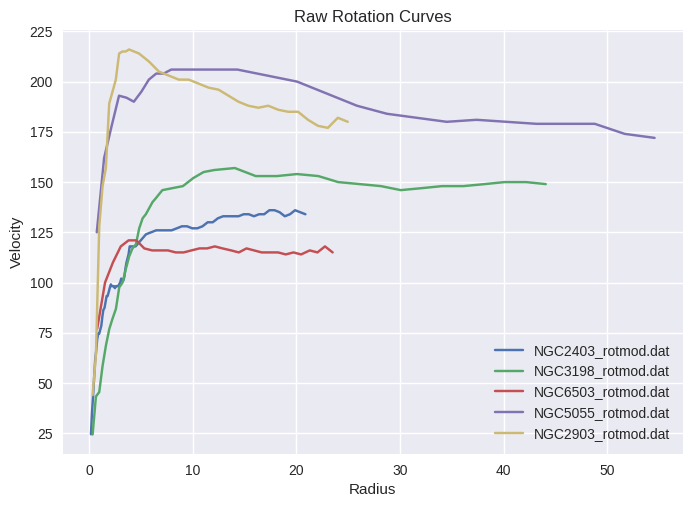

In [10]:
import matplotlib.pyplot as plt

for name, (r, v) in galaxies.items():
    plt.plot(r, v, label=name)

plt.legend()
plt.xlabel("Radius")
plt.ylabel("Velocity")
plt.title("Raw Rotation Curves")
plt.show()